In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

REPO_ROOT = Path("..").resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

CSV_PATH = REPO_ROOT / "data" / "HAM10000" / "ham_test_cam_all_with_masks_grouped_by_class.csv"
IMG_DIR = REPO_ROOT / "data" / "HAM10000"

CHECKPOINT = REPO_ROOT / "external" / "checkpoints3" / "checkpoint-best-HA075.pth"
CHECKPOINT_MODEL_TYPE = "panderm"

DEVICE = None  # auto

print("CSV:", CSV_PATH)
print("Checkpoint:", CHECKPOINT)

CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/ham_test_cam_all_with_masks_grouped_by_class.csv
Checkpoint: /Users/choekyelnyungmartsang/Developer/master-thesis/external/checkpoints3/checkpoint-best-HA075.pth


In [2]:
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
from tqdm.auto import tqdm

from scripts.generate_finer_cam_panderm import (
    load_panderm_finetuned_model,
    resolve_class_names,
    build_class_maps,
)

from types import SimpleNamespace


def get_device(device_arg=None):
    if device_arg is not None:
        return device_arg
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


def build_eval_transform(image_size=224):
    return T.Compose([
        T.Resize(256),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.228, 0.224, 0.225),
        ),
    ])


def resolve_image_path(row, img_dir: Path):
    p = Path(str(row["image_rel_path"]))
    if p.is_absolute():
        return p
    return img_dir / p


def load_rgb(path: Path):
    return Image.open(path).convert("RGB")

In [3]:
df = pd.read_csv(CSV_PATH)

required_cols = ["image_id", "image_rel_path", "gt_label", "label", "split"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[df["split"] == "test"].copy()
df = df.reset_index(drop=True)

print("Number of test images:", len(df))
display(df[["image_id", "gt_label", "label", "image_rel_path"]].head())
display(df["gt_label"].value_counts())

Number of test images: 1232


,image_id,gt_label,label,image_rel_path
0,ISIC_0024459,MEL,4,images/ISIC_0024459.jpg
1,ISIC_0024571,MEL,4,images/ISIC_0024571.jpg
2,ISIC_0024624,MEL,4,images/ISIC_0024624.jpg
3,ISIC_0024640,MEL,4,images/ISIC_0024640.jpg
4,ISIC_0024756,MEL,4,images/ISIC_0024756.jpg


gt_label
NV       951
BKL      107
MEL       70
BCC       44
AKIEC     35
VASC      17
DF         8
Name: count, dtype: int64

In [4]:
device = get_device(DEVICE)
print("Device:", device)

args_for_classes = SimpleNamespace(class_preset="ham", class_names=None)
class_names = resolve_class_names(args_for_classes)

class_to_idx, idx_to_class = build_class_maps(class_names)

print("Class names:", class_names)

model, model_info = load_panderm_finetuned_model(
    checkpoint_path=str(CHECKPOINT),
    num_classes=len(class_names),
    class_to_idx=class_to_idx,
    idx_to_class=idx_to_class,
    device=device,
    checkpoint_model_type=CHECKPOINT_MODEL_TYPE,
    use_seg_gate=False,
)

model.eval()
transform = build_eval_transform()

print("Loaded model.")
print(model_info)

Device: mps
Class names: ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
Loaded model.
{'arch': 'PanDerm Base FT', 'variant': 'base', 'num_classes': 7, 'checkpoint_name': 'checkpoint-best-HA075.pth', 'checkpoint_format': 'official_pth', 'checkpoint_model_type': 'panderm', 'use_seg_gate': False, 'seg_gate_bg_keep': 0.15, 'seg_gate_detach': True, 'class_to_idx': {'AKIEC': 0, 'BCC': 1, 'BKL': 2, 'DF': 3, 'MEL': 4, 'NV': 5, 'VASC': 6}, 'idx_to_class': {0: 'AKIEC', 1: 'BCC', 2: 'BKL', 3: 'DF', 4: 'MEL', 5: 'NV', 6: 'VASC'}, 'image_size': 224, 'stage_name': None, 'epoch': 'best'}


In [5]:
rows = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Inference"):
    image_id = str(row["image_id"])
    gt_idx = int(row["label"])
    gt_name = str(row["gt_label"])

    image_path = resolve_image_path(row, IMG_DIR)

    try:
        image = load_rgb(image_path)
        x = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

        pred_idx = int(np.argmax(probs))
        pred_name = class_names[pred_idx]
        pred_conf = float(probs[pred_idx])
        gt_conf = float(probs[gt_idx])

        rows.append({
            "image_id": image_id,
            "gt_idx": gt_idx,
            "gt_name": gt_name,
            "pred_idx": pred_idx,
            "pred_name": pred_name,
            "pred_confidence": pred_conf,
            "gt_confidence": gt_conf,
            "correct": pred_idx == gt_idx,
        })

    except Exception as e:
        rows.append({
            "image_id": image_id,
            "gt_idx": gt_idx,
            "gt_name": gt_name,
            "status": "failed",
            "error": str(e),
        })

pred_df = pd.DataFrame(rows)

out_path = REPO_ROOT / "outputs" / "ha075_test_predictions.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
pred_df.to_csv(out_path, index=False)

print("Saved:", out_path)
display(pred_df.head())

Inference:   0%|          | 0/1232 [00:00<?, ?it/s]

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/ha075_test_predictions.csv


,image_id,gt_idx,gt_name,pred_idx,pred_name,pred_confidence,gt_confidence,correct
0,ISIC_0024459,4,MEL,4,MEL,0.921585,0.921585,True
1,ISIC_0024571,4,MEL,4,MEL,0.999477,0.999477,True
2,ISIC_0024624,4,MEL,4,MEL,0.549110,0.549110,True
3,ISIC_0024640,4,MEL,4,MEL,0.992801,0.992801,True
4,ISIC_0024756,4,MEL,4,MEL,0.990277,0.990277,True


In [7]:
if "status" in pred_df.columns:
    ok_df = pred_df[pred_df["status"].fillna("ok") != "failed"].copy()
else:
    ok_df = pred_df.copy()

class_metric = (
    ok_df
    .groupby("gt_name")
    .agg(
        n_test=("image_id", "count"),
        n_correct=("correct", "sum"),
        class_recall=("correct", "mean"),
        mean_gt_confidence=("gt_confidence", "mean"),
    )
    .reset_index()
)

class_metric["class_recall_percent"] = class_metric["class_recall"] * 100
class_metric["mean_gt_confidence_percent"] = class_metric["mean_gt_confidence"] * 100

class_metric = class_metric.sort_values("class_recall", ascending=False)

display(class_metric)

,gt_name,n_test,n_correct,class_recall,mean_gt_confidence,class_recall_percent,mean_gt_confidence_percent
3,DF,8,8,1.000000,0.949674,100.000000,94.967441
6,VASC,17,17,1.000000,0.953600,100.000000,95.359998
5,NV,951,854,0.898002,0.885803,89.800210,88.580256
1,BCC,44,39,0.886364,0.895269,88.636364,89.526927
2,BKL,107,92,0.859813,0.808856,85.981308,80.885570
4,MEL,70,57,0.814286,0.797447,81.428571,79.744667
0,AKIEC,35,21,0.600000,0.592141,60.000000,59.214114


In [8]:
clinician_table = class_metric.copy()

clinician_table["Class"] = clinician_table["gt_name"]
clinician_table["Test cases"] = clinician_table["n_test"].astype(int)
clinician_table["Correctly detected"] = (
    clinician_table["n_correct"].astype(int).astype(str)
    + " / "
    + clinician_table["n_test"].astype(int).astype(str)
)
clinician_table["Sensitivity"] = clinician_table["class_recall_percent"].map(lambda x: f"{x:.1f}%")
clinician_table["Mean confidence for true class"] = clinician_table["mean_gt_confidence_percent"].map(lambda x: f"{x:.1f}%")

clinician_table = clinician_table[[
    "Class",
    "Test cases",
    "Correctly detected",
    "Sensitivity",
    "Mean confidence for true class",
]]

display(clinician_table)

out_path = REPO_ROOT / "outputs" / "ha075_per_class_sensitivity_clinician_table.csv"
clinician_table.to_csv(out_path, index=False)

print("Saved:", out_path)

,Class,Test cases,Correctly detected,Sensitivity,Mean confidence for true class
3,DF,8,8 / 8,100.0%,95.0%
6,VASC,17,17 / 17,100.0%,95.4%
5,NV,951,854 / 951,89.8%,88.6%
1,BCC,44,39 / 44,88.6%,89.5%
2,BKL,107,92 / 107,86.0%,80.9%
4,MEL,70,57 / 70,81.4%,79.7%
0,AKIEC,35,21 / 35,60.0%,59.2%


Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/ha075_per_class_sensitivity_clinician_table.csv


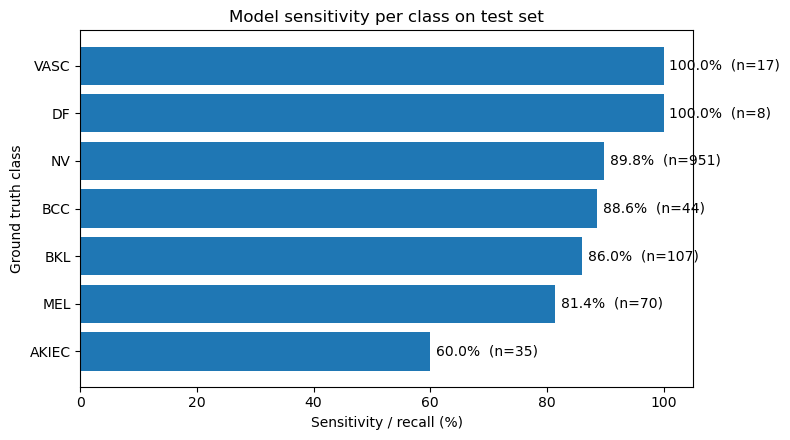

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/ha075_per_class_sensitivity_barplot.png


In [9]:
import matplotlib.pyplot as plt

plot_df = class_metric.sort_values("class_recall", ascending=True).copy()

plt.figure(figsize=(8, 4.5))
plt.barh(plot_df["gt_name"], plot_df["class_recall_percent"])

for i, row in enumerate(plot_df.itertuples()):
    plt.text(
        row.class_recall_percent + 1,
        i,
        f"{row.class_recall_percent:.1f}%  (n={row.n_test})",
        va="center",
    )

plt.xlabel("Sensitivity / recall (%)")
plt.ylabel("Ground truth class")
plt.title("Model sensitivity per class on test set")
plt.xlim(0, 105)
plt.tight_layout()

plot_path = REPO_ROOT / "outputs" / "ha075_per_class_sensitivity_barplot.png"
plt.savefig(plot_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", plot_path)